In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Imports and Connections
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Load Local Inverter Data from CSV
# ─────────────────────────────────────────────────────────────

# Update path to where your CSV is saved on your laptop
csv_path = r"D:\Desktop\ESSCO\essco-ai\Dataset\TKKHEAD01\semply_cloud.meter.solar.1.csv" 

df_inverter = pd.read_csv(csv_path)

# 1. Standardize column mapping (Ensuring 'timestamp' and 'ac_power_total')
df_inverter = df_inverter.rename(columns={
    "dateTime": "timestamp",
    "pTot": "ac_power_total"
})

# 2. Keep only required columns and remove missing records
keep_cols = ["timestamp", "ac_power_total"]
df_inverter = df_inverter[keep_cols].dropna(subset=["ac_power_total"])

print(f"✅ Inverter CSV data loaded → shape: {df_inverter.shape}")
print(f"   Date range: {df_inverter['timestamp'].min()}  →  {df_inverter['timestamp'].max()}\n")
df_inverter.head(3)


✅ Inverter CSV data loaded → shape: (316922, 2)
   Date range: 2025-11-08T03:46:23.000Z  →  2026-06-19T12:54:01.000Z



,timestamp,ac_power_total
0,2026-06-19T12:54:01.000Z,23.20
1,2026-06-19T12:53:01.000Z,17.22
2,2026-06-19T12:52:01.000Z,22.10


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Fetch Enhanced Weather Data via Open-Meteo API
# ─────────────────────────────────────────────────────────────
import pandas as pd
import requests

# 1. Automatically match the time range of your historical CSV
start_date = pd.to_datetime(df_inverter['timestamp'].min()).strftime('%Y-%m-%d')
end_date = pd.to_datetime(df_inverter['timestamp'].max()).strftime('%Y-%m-%d')

# 2. Configure Open-Meteo API parameters
latitude = 13.7275   
longitude = 100.7781 

url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "minutely_15": "direct_radiation,temperature_2m,relative_humidity_2m,cloud_cover",
    "timezone": "UTC"
}

print(f"🌐 Fetching Open-Meteo historical 15-min weather features from {start_date} to {end_date}...")
response = requests.get(url, params=params).json()

if "error" in response:
    raise ValueError(f"Open-Meteo API Error: {response['reason']}")

# 3. Parse 15-minute multi-variable weather data
minutely_data = response[
    "minutely_15"
]

df_weather = pd.DataFrame({
    "timestamp": minutely_data["time"],
    "solar_irradiance": minutely_data["direct_radiation"],
    "temperature": minutely_data["temperature_2m"],
    "relative_humidity": minutely_data["relative_humidity_2m"],
    "cloud_cover": minutely_data["cloud_cover"]
})

df_weather = df_weather.dropna(subset=["solar_irradiance"])

print(f"✅ Enhanced Weather data loaded → shape: {df_weather.shape}")
print(f"   Date range: {df_weather['timestamp'].min()}  →  {df_weather['timestamp'].max()}")
df_weather.head(3)


🌐 Fetching Open-Meteo historical 15-min weather features from 2025-11-08 to 2026-06-19...
✅ Enhanced Weather data loaded → shape: (21504, 5)
   Date range: 2025-11-08T00:00  →  2026-06-19T23:45


,timestamp,solar_irradiance,temperature,relative_humidity,cloud_cover
0,2025-11-08T00:00,7.0,25.1,97,88
1,2025-11-08T00:15,16.0,25.5,96,89
2,2025-11-08T00:30,28.0,25.8,95,92


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Resample All Sources to 5-Minute Grid & Merge
# ─────────────────────────────────────────────────────────────

def to_utc_index(df: pd.DataFrame, ts_col: str = "timestamp") -> pd.DataFrame:
    """Convert a timestamp column to a UTC-aware DatetimeIndex."""
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    if df[ts_col].dt.tz is None:
        df[ts_col] = df[ts_col].dt.tz_localize("UTC")
    else:
        df[ts_col] = df[ts_col].dt.tz_convert("UTC")
    df = df.set_index(ts_col).sort_index()
    return df

# ── 1. Inverter (CSV) — 5-min mean from 'pTot' ─────────────────
df_inverter = to_utc_index(df_inverter)
df_inverter = df_inverter.resample("5min").mean()
print(f"✅ df_inverter  resampled → {df_inverter.shape}")

# ── 2. Weather — 5-min resample and interpolate ────────────────
df_weather = to_utc_index(df_weather)
df_weather = df_weather.resample("5min").mean().interpolate(method="time")
print(f"✅ df_weather   resampled → {df_weather.shape}")

# ── 3. Combine into a Single Master Dataset for Analysis ──────
df_master = df_inverter.join(df_weather, how="inner")

# Convert index to local Thai time for proper feature extraction
df_master.index = df_master.index.tz_convert("Asia/Bangkok")

# Extract temporal features
df_master['hour'] = df_master.index.hour
df_master['month'] = df_master.index.month
df_master['date'] = df_master.index.date

print(f"\n✅ Master DataFrame created → shape: {df_master.shape}")
print("📋 All sources aligned and enriched with time features.")


✅ df_inverter  resampled → (64334, 1)
✅ df_weather   resampled → (64510, 4)

✅ Master DataFrame created → shape: (64334, 8)
📋 All sources aligned and enriched with time features.


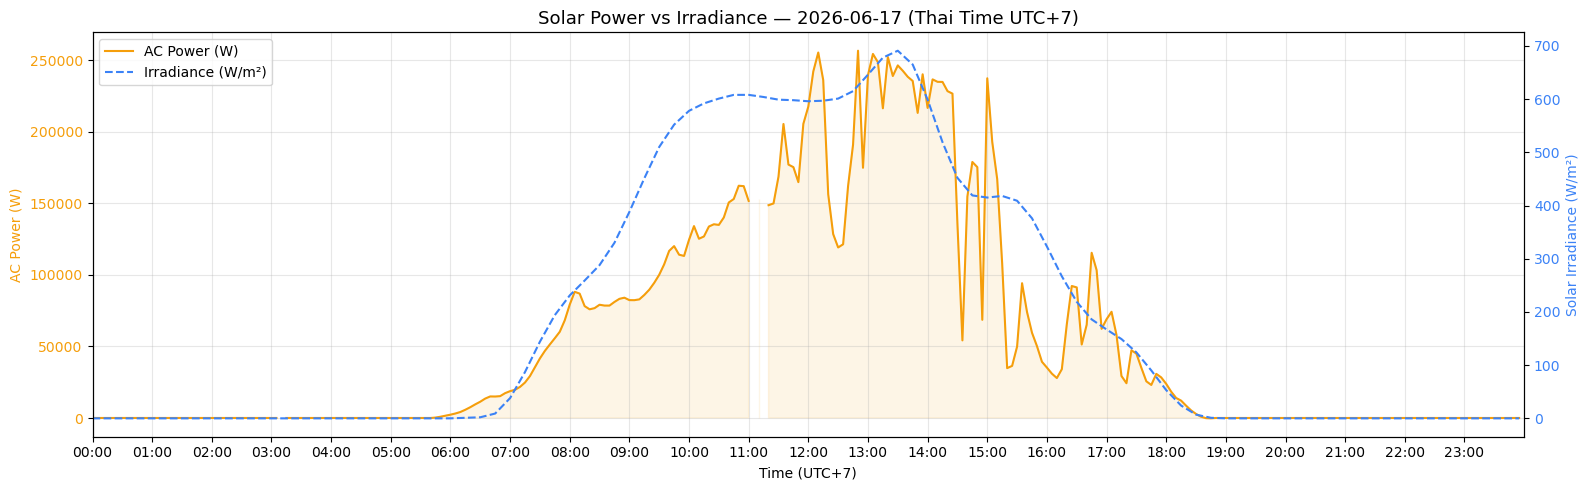

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Plot Solar Power vs Irradiance (Single Day View)
# ─────────────────────────────────────────────────────────────

TARGET_DATE = "2026-06-17"  # ← change to any date

day_start = pd.Timestamp(TARGET_DATE + " 00:00:00", tz="Asia/Bangkok")
day_end   = pd.Timestamp(TARGET_DATE + " 23:59:59", tz="Asia/Bangkok")

# Filter master dataframe to target day
df_day = df_master[(df_master.index >= day_start) & (df_master.index <= day_end)]

# Strip tz for matplotlib plotting
day_times = df_day.index.tz_localize(None)

xlim_start = pd.Timestamp(TARGET_DATE + " 00:00:00")
xlim_end   = pd.Timestamp(TARGET_DATE + " 23:59:59")

# ── Dual-axis plot ──────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 5))

# Left axis — AC Power
ax1.plot(day_times, df_day["ac_power_total"],
         color="#f59e0b", linewidth=1.5, label="AC Power (W)")
ax1.fill_between(day_times, df_day["ac_power_total"],
                 alpha=0.10, color="#f59e0b")
ax1.set_ylabel("AC Power (W)", color="#f59e0b")
ax1.tick_params(axis="y", labelcolor="#f59e0b")

# Right axis — Solar Irradiance
ax2 = ax1.twinx()
ax2.plot(day_times, df_day["solar_irradiance"],
         color="#3b82f6", linewidth=1.5, linestyle="--", label="Irradiance (W/m²)")
ax2.set_ylabel("Solar Irradiance (W/m²)", color="#3b82f6")
ax2.tick_params(axis="y", labelcolor="#3b82f6")

# X-axis
ax1.set_xlim(xlim_start, xlim_end)
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=45)

# Legend — combine both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title(f"Solar Power vs Irradiance — {TARGET_DATE} (Thai Time UTC+7)", fontsize=13)
ax1.set_xlabel("Time (UTC+7)")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


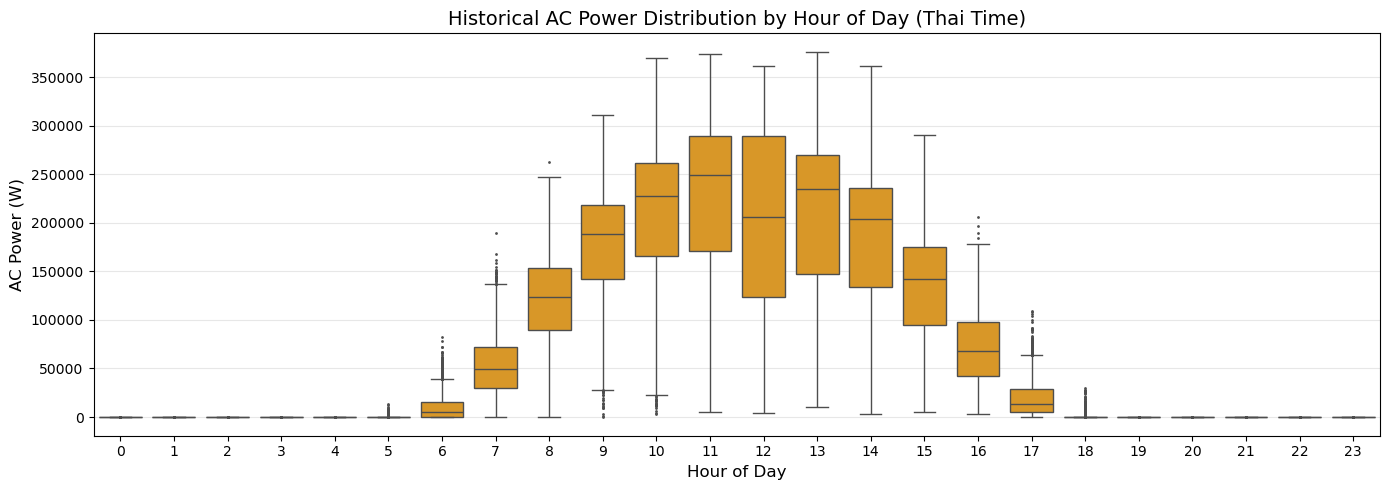

In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Hour-of-Day Boxplot (Diurnal Pattern Distribution)
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(14, 5))
sns.boxplot(data=df_master, x="hour", y="ac_power_total", color="#f59e0b", fliersize=1)
plt.title("Historical AC Power Distribution by Hour of Day (Thai Time)", fontsize=14)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("AC Power (W)", fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


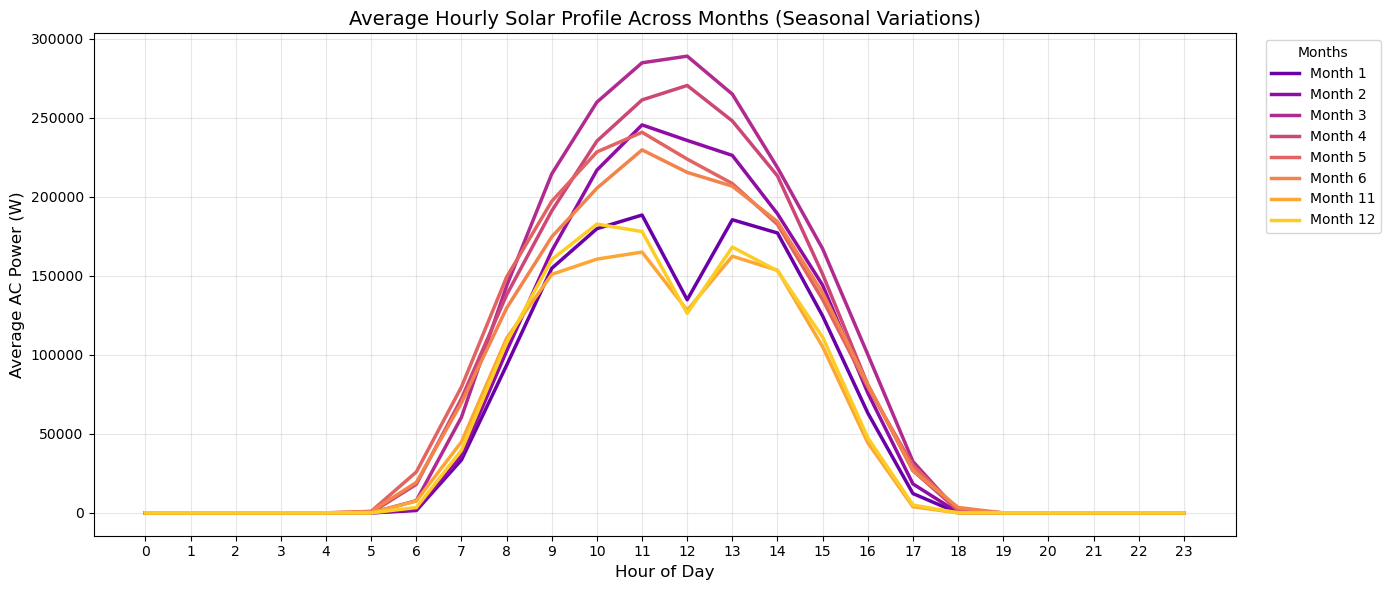

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Month-of-Year Line Plot (Seasonal Profiles)
# ─────────────────────────────────────────────────────────────

monthly_profile = df_master.groupby(['month', 'hour'])['ac_power_total'].mean().unstack(level=0)

plt.figure(figsize=(14, 6))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(monthly_profile.columns)))
for i, m in enumerate(monthly_profile.columns):
    plt.plot(monthly_profile.index, monthly_profile[m], label=f"Month {m}", color=colors[i], linewidth=2.5)

plt.title("Average Hourly Solar Profile Across Months (Seasonal Variations)", fontsize=14)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Average AC Power (W)", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Months")
plt.tight_layout()
plt.show()


LinAlgError: SVD did not converge in Linear Least Squares

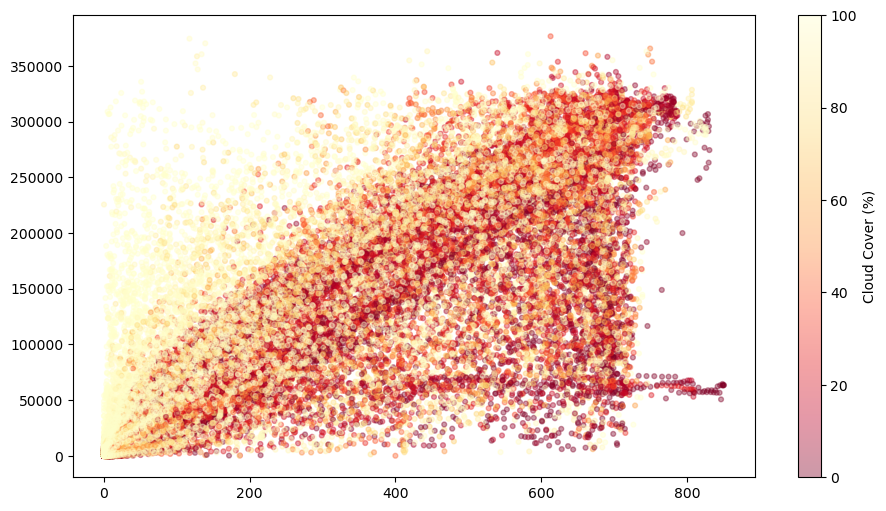

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Historical Scatter Plot: AC Power vs. Irradiance
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(11, 6))
sc = plt.scatter(df_master['solar_irradiance'], df_master['ac_power_total'], 
                 c=df_master['cloud_cover'], cmap='YlOrRd_r', alpha=0.4, s=12)
plt.colorbar(sc, label="Cloud Cover (%)")

# Fit a trendline
poly_fit = np.polyfit(df_master['solar_irradiance'], df_master['ac_power_total'], 1)
trend_poly = np.poly1d(poly_fit)
x_vals = np.linspace(0, df_master['solar_irradiance'].max(), 100)
plt.plot(x_vals, trend_poly(x_vals), color="#1e293b", linestyle="--", linewidth=2, label="Linear Trendline")

plt.title("AC Power vs. Open-Meteo Solar Irradiance (Colored by Cloud Cover)", fontsize=14)
plt.xlabel("Solar Irradiance (W/m²)", fontsize=12)
plt.ylabel("AC Power (W)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


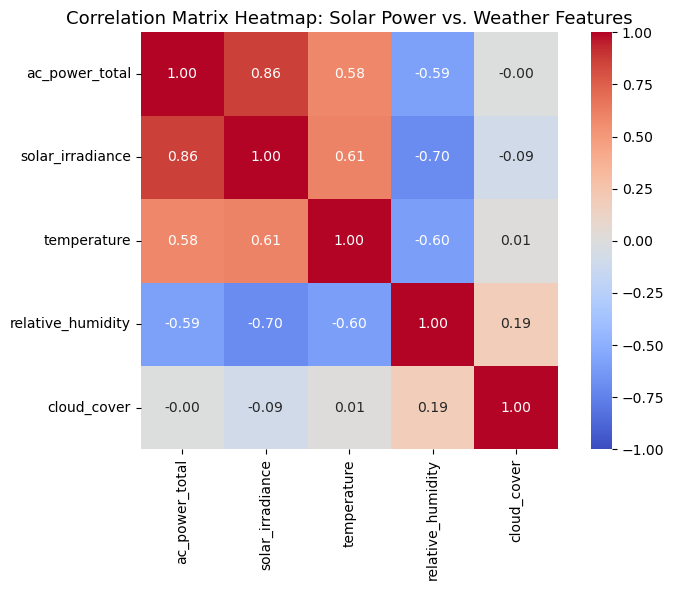

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Multi-Variable Weather Correlation Heatmap
# ─────────────────────────────────────────────────────────────

corr_cols = ["ac_power_total", "solar_irradiance", "temperature", "relative_humidity", "cloud_cover"]
corr_matrix = df_master[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix Heatmap: Solar Power vs. Weather Features", fontsize=13)
plt.tight_layout()
plt.show()


In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Nighttime Baseline Diagnostics
# ─────────────────────────────────────────────────────────────

df_night = df_master[(df_master['hour'] >= 20) | (df_master['hour'] <= 4)]

print("--- 🌙 Nighttime (20:00 - 04:00) Target Value Diagnostics ---")
print(f"Total nighttime observations: {len(df_night)}")
print(f"Minimum AC Power: {df_night['ac_power_total'].min()} W")
print(f"Maximum AC Power: {df_night['ac_power_total'].max()} W")
print(f"Average AC Power: {df_night['ac_power_total'].mean():.2f} W")

if (df_night['ac_power_total'].abs() > 0.1).any():
    print("\n💡 Recommendation: Inverter standby noise/consumption detected.")
    print("   Before training your model, apply this preprocessing rule to prevent model confusion:")
    print("   df_master.loc[(df_master['hour'] >= 19) | (df_master['hour'] <= 5), 'ac_power_total'] = 0")
else:
    print("\n✅ Perfect baseline! Solar power is exactly zero at night.")


--- 🌙 Nighttime (20:00 - 04:00) Target Value Diagnostics ---
Total nighttime observations: 24084
Minimum AC Power: 15.551999999999998 W
Maximum AC Power: 33.577999999999996 W
Average AC Power: 21.28 W

💡 Recommendation: Inverter standby noise/consumption detected.
   Before training your model, apply this preprocessing rule to prevent model confusion:
   df_master.loc[(df_master['hour'] >= 19) | (df_master['hour'] <= 5), 'ac_power_total'] = 0
